# Walmart Sales Analysis
### By Varsha Agarwal

## Business Question
Which product lines, branches, and customer segments drive the most revenue — 
and where should Walmart focus to improve performance?

## Dataset
1000 transactions across 3 branches (A, B, C) covering January to March 2019.
17 variables including product line, customer type, payment method, and ratings.

## Key Findings

1. **Health & Beauty has a pricing problem** — highest customer satisfaction but 
lowest revenue due to lowest unit prices. Opportunity to reprice upward.

2. **Branch B is underperforming** — lowest revenue and lowest customer rating. 
Needs operational review.

3. **January is peak month** — February drops by 16%. Seasonal promotions needed.

4. **Female customers drive more revenue** — especially in Food & Beverages. 
Males dominate Health & Beauty and Sports & Travel.

5. **Critical insight: Customer satisfaction does NOT drive revenue** — 
correlation between Rating and Total is only -0.036. Revenue is driven by 
Quantity (0.70) and Unit Price (0.63).

## Recommendation
- Increase price points in Health & Beauty — customers are already satisfied
- Audit Branch B operations immediately
- Focus on upselling strategies to increase basket size, not just satisfaction scores
- Launch targeted February promotions to recover the seasonal dip

## Tools Used
Python | Pandas | Matplotlib | Jupyter Notebook

In [7]:
import pandas as pd
df = pd.read_csv("C:/Users/agarw/Downloads/Walmart Sales Data.csv.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [9]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [11]:
df.groupby('Product line')['Total'].sum().sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

In [13]:
df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64

In [15]:
df.groupby('Product line')['Quantity'].mean().sort_values(ascending=False)

Product line
Electronic accessories    5.711765
Home and lifestyle        5.693750
Health and beauty         5.618421
Sports and travel         5.542169
Food and beverages        5.471264
Fashion accessories       5.067416
Name: Quantity, dtype: float64

In [17]:
df.groupby('Product line')['Unit price'].mean().sort_values(ascending=False)

Product line
Fashion accessories       57.153652
Sports and travel         56.993253
Food and beverages        56.008851
Home and lifestyle        55.316937
Health and beauty         54.854474
Electronic accessories    53.551588
Name: Unit price, dtype: float64

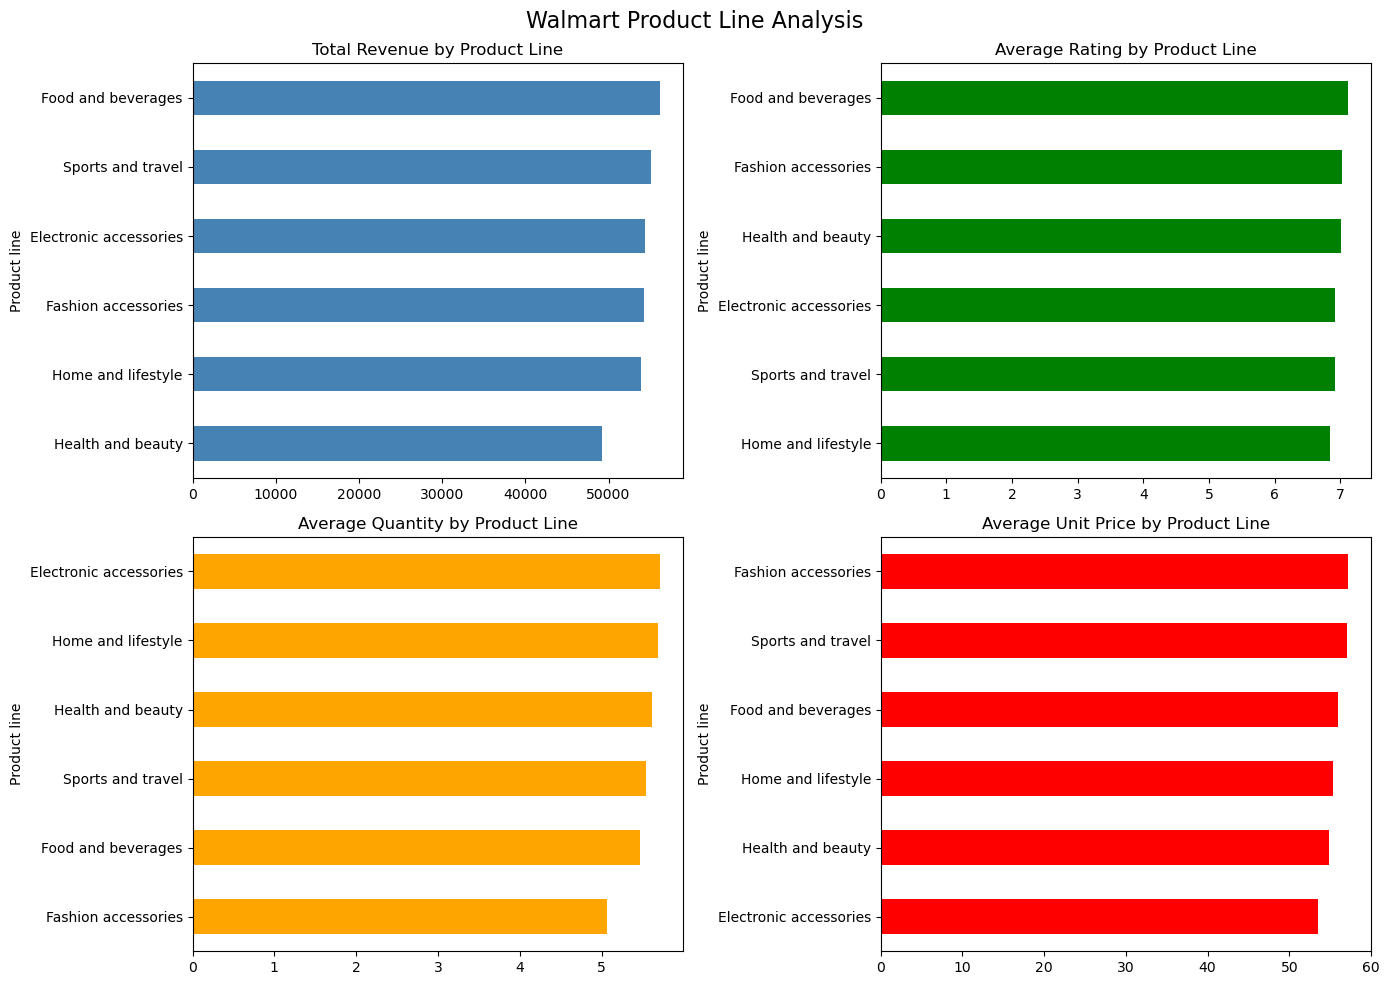

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Walmart Product Line Analysis', fontsize=16)

df.groupby('Product line')['Total'].sum().sort_values().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Revenue by Product Line')

df.groupby('Product line')['Rating'].mean().sort_values().plot(kind='barh', ax=axes[0,1], color='green')
axes[0,1].set_title('Average Rating by Product Line')

df.groupby('Product line')['Quantity'].mean().sort_values().plot(kind='barh', ax=axes[1,0], color='orange')
axes[1,0].set_title('Average Quantity by Product Line')

df.groupby('Product line')['Unit price'].mean().sort_values().plot(kind='barh', ax=axes[1,1], color='red')
axes[1,1].set_title('Average Unit Price by Product Line')

plt.tight_layout()
plt.savefig('product_line_analysis.png')
plt.show()

In [21]:
df.groupby('Branch')['Total'].sum().sort_values(ascending=False)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64

In [23]:
df.groupby('Branch')['Rating'].mean().sort_values(ascending=False)

Branch
C    7.072866
A    7.027059
B    6.818072
Name: Rating, dtype: float64

In [25]:
df.groupby('Branch')['gross income'].sum().sort_values(ascending=False)

Branch
C    5265.1765
A    5057.1605
B    5057.0320
Name: gross income, dtype: float64

In [27]:
df.groupby('Payment')['Total'].sum().sort_values(ascending=False)

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64

In [29]:
df.groupby('Customer type')['Total'].sum().sort_values(ascending=False)

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64

In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
df.groupby('Month')['Total'].sum().sort_values(ascending=False)

Month
January     116291.868
March       109455.507
February     97219.374
Name: Total, dtype: float64

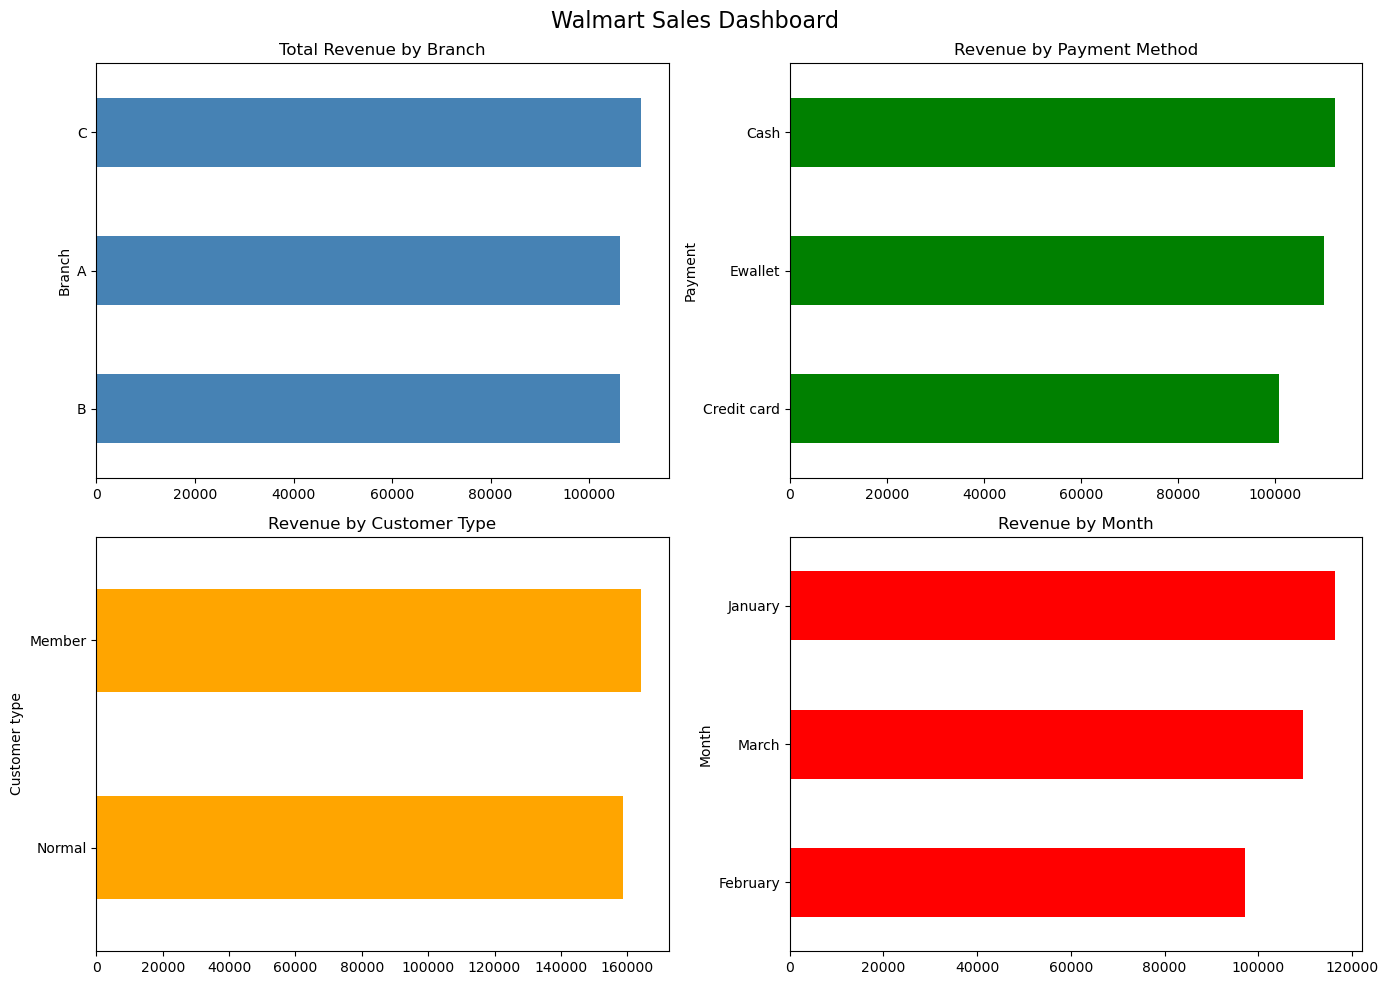

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Walmart Sales Dashboard', fontsize=16)

df.groupby('Branch')['Total'].sum().sort_values().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Revenue by Branch')

df.groupby('Payment')['Total'].sum().sort_values().plot(kind='barh', ax=axes[0,1], color='green')
axes[0,1].set_title('Revenue by Payment Method')

df.groupby('Customer type')['Total'].sum().sort_values().plot(kind='barh', ax=axes[1,0], color='orange')
axes[1,0].set_title('Revenue by Customer Type')

df.groupby('Month')['Total'].sum().sort_values().plot(kind='barh', ax=axes[1,1], color='red')
axes[1,1].set_title('Revenue by Month')

plt.tight_layout()
plt.savefig('walmart_dashboard.png')
plt.show()

In [36]:
df.groupby('Gender')['Total'].sum().sort_values(ascending=False)

Gender
Female    167882.925
Male      155083.824
Name: Total, dtype: float64

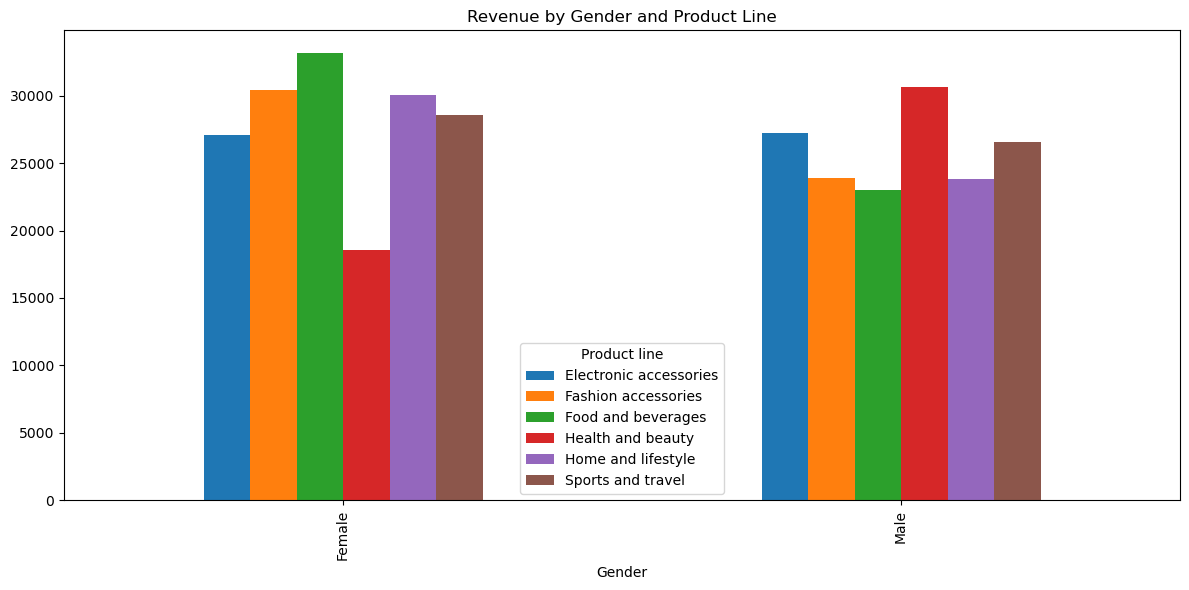

In [40]:
df.groupby(['Gender', 'Product line'])['Total'].sum().unstack().plot(kind='bar', figsize=(12,6))
plt.title('Revenue by Gender and Product Line')
plt.tight_layout()
plt.savefig('gender_product_analysis.png')
plt.show()

In [42]:
df[['Unit price', 'Total', 'Rating', 'Quantity']].corr()

,Unit price,Total,Rating,Quantity
Unit price,1.000000,0.633962,-0.008778,0.010778
Total,0.633962,1.000000,-0.036442,0.705510
Rating,-0.008778,-0.036442,1.000000,-0.015815
Quantity,0.010778,0.705510,-0.015815,1.000000
